In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle
plt.style.use(['science','no-latex'])#,'notebook'])

colors = ["#1982c4", "black", "#ff595e", "#20b806"]

### Transfer entropy

In [8]:
taus, TEs_X_to_Y, TEs_Y_to_X = pickle.load(open("pickles_te/allseeds.p","rb"))
ntrajs = TEs_X_to_Y.shape[0]

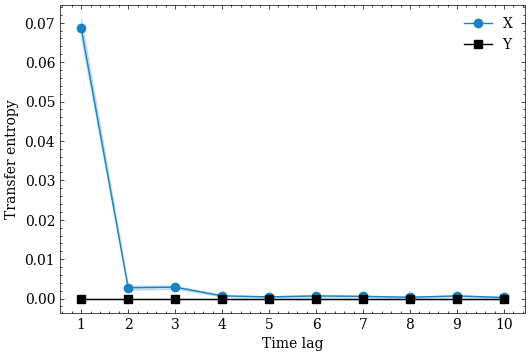

Expected:	0.06790000000000007
Measured:	0.06865158124413953


In [9]:
plt.figure(figsize=(6, 4))

# x->y
mean = TEs_X_to_Y.mean(axis=0)
err = TEs_X_to_Y.std(axis=0, ddof=1) / np.sqrt(ntrajs)
plt.plot(taus, mean, 'o-', label="X", color=colors[0])
plt.fill_between(taus, mean - err, mean + err, alpha=0.2, color=colors[0])
# y->x variable
mean = TEs_Y_to_X.mean(axis=0)
err = TEs_Y_to_X.std(axis=0, ddof=1) / np.sqrt(ntrajs)
plt.plot(taus, mean, 's-', label="Y", color=colors[1])
plt.fill_between(taus, mean - err, mean + err, alpha=0.2, color=colors[1])
# labels
plt.xticks(taus)
plt.xlabel("Time lag")
plt.ylabel("Transfer entropy")
plt.legend()
#plt.savefig("./figures/TE_markov.pdf", dpi=300)
plt.show()

print(f"Expected:\t{0.6316 - 0.5637}")
print(f"Measured:\t{TEs_X_to_Y.mean(axis=0)[0]}")

### Imbalance Gain

In [10]:
def compute_IGs(imbalances, correction=True):    
    n_indep_realizations = imbalances.shape[0]
    n_taus = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_taus),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_taus),alphas_max] / np.sqrt(n_indep_realizations)

    if correction:
        IGs[imbalances[:,:,0].mean(axis=0) > 1] = 0
        errors[imbalances[:,:,0].mean(axis=0) > 1] = 0
        
    return IGs, errors

In [14]:
k = 20
taus = np.arange(1,11)
seeds = np.arange(20)
alphas = np.linspace(0,20,500)
imbs_X_to_Y = np.zeros((len(seeds), len(taus), len(alphas)))
imbs_Y_to_X = np.zeros((len(seeds), len(taus), len(alphas)))

for seed in seeds:
    taus, alphas, imbs_X_to_Y[seed], imbs_Y_to_X[seed] = pickle.load(open(f"pickles_ig/seed{seed}_k{k}.p","rb"))

IGs_X_to_Y, errs_X_to_Y = compute_IGs(imbs_X_to_Y, correction=True)
IGs_Y_to_X, errs_Y_to_X = compute_IGs(imbs_Y_to_X, correction=True)

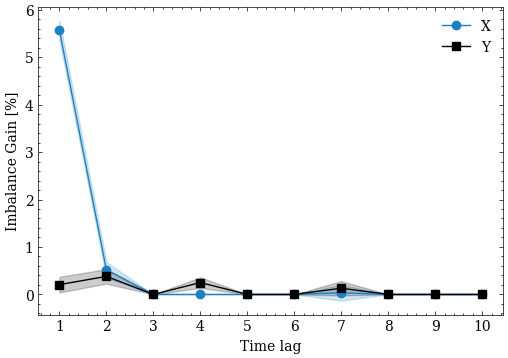

In [15]:
plt.figure(figsize=(6, 4))

# x->y
plt.plot(taus, IGs_X_to_Y, 'o-', label="X", color=colors[0])
plt.fill_between(taus, IGs_X_to_Y - errs_X_to_Y, IGs_X_to_Y + errs_X_to_Y, alpha=0.2, color=colors[0])
# y->x
plt.plot(taus, IGs_Y_to_X, 's-', label="Y", color=colors[1])
plt.fill_between(taus, IGs_Y_to_X - errs_Y_to_X, IGs_Y_to_X + errs_Y_to_X, alpha=0.2, color=colors[1])
# labels
plt.xticks(taus)
plt.xlabel("Time lag")
plt.ylabel("Imbalance Gain [%]")
plt.legend()
#plt.savefig("./figures/IG_markov.pdf", dpi=300)
plt.show()

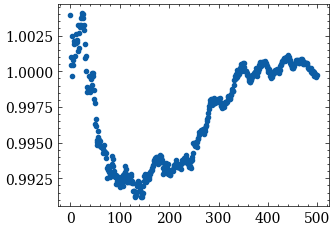

In [20]:
plt.plot(imbs_X_to_Y[2,2], '.')